# 🌲 06 — Random Forest Model Training & Evaluation

This notebook trains **Random Forest** models for regression and classification on the model-ready air quality dataset. 

### 🧒 Easy guide (Inputs & Outputs)
- **Input:** data files in `data/processed/` (train/val/test or full dataset).
- Each row is one forest plot. **Features** are clues; the **target** is the answer.
- **Output:** trained models saved in `outputs/models/`, scores saved in `outputs/reports/`, and plots shown on screen.
- **Random Forest** means many small trees vote on the answer.

### ✅ If accuracy is 1.0 | leakage check
If classification or regression performance becomes **almost perfect**, that is often a sign of **data leakage**, not true generalisation.

In this notebook, classification and regression are restricted to a **leakage-safe feature subset** so that the reported results are realistic and reproducible.


## 0. Setup & Imports

This cell sets up the folder and helps Colab users download the project.

In [1]:
# ── Google Colab & Local auto-setup ─────────────────────────────────────────-

import os, sys



# 1. FIX WORKING DIRECTORY (Crucial for VS Code)

# If running from notebooks/ subdir, move up to repo root

if os.path.basename(os.getcwd()) == 'notebooks':

    os.chdir('..')



# Ensure repo root is in sys.path so 'src' is importable

repo_root = os.getcwd()

if repo_root not in sys.path:

    sys.path.insert(0, repo_root)



# 2. GOOGLE COLAB WORKFLOW

if 'google.colab' in sys.modules:

    REPO_DIR = 'Air_Quality_Predictor'

    # Clone the repo if not already done

    if not os.path.exists(REPO_DIR):

        !git clone https://github.com/shashi2024/Air_Quality_Predictor.git

    os.chdir(REPO_DIR)



    # Install dependencies

    !pip install -r requirements.txt -q



    # Run the data pipeline notebooks (01-05) if processed data doesn't exist

    import subprocess

    data_ready = (

        os.path.exists(os.path.join('data', 'processed', 'train.parquet')) or

        os.path.exists(os.path.join('data', 'processed', 'train.csv'))

    )

    if not data_ready:

        print('⏳ Running data pipeline notebooks 01-05... (this may take 10-20 minutes)')

        for nb_name in [

            '01_data_ingestion', '02_eda_exploration', '03_preprocessing',

            '04_feature_extraction', '05_model_ready_dataset'

        ]:

            nb_path = os.path.join('notebooks', f'{nb_name}.ipynb')

            print(f'   ▶ Running {nb_name}.ipynb ...')

            result = subprocess.run(

                ['jupyter', 'nbconvert', '--to', 'notebook', '--execute',

                 '--ExecutePreprocessor.timeout=1800',

                 '--ExecutePreprocessor.kernel_name=python3',

                 nb_path, '--output', nb_path],

                capture_output=True, text=True

            )

            if result.returncode != 0:

                print(f'   ⚠️  {nb_name} had warnings/errors\n{result.stderr[-300:]}')

            else:

                print(f'   ✅ {nb_name} done')

        print('✅ Data pipeline complete!')

    else:

        print('✅ Processed data already exists, skipping pipeline notebooks.')



print(f'Working directory: {os.getcwd()}')

print(f'src/ exists: {os.path.exists("src")}')

print(f'data/processed/ exists: {os.path.exists(os.path.join("data", "processed"))}')

Working directory: c:\Users\94752\Desktop\ML\Air_Quality_Predictor
src/ exists: True
data/processed/ exists: True


This cell loads the tools (libraries) we will use.

In [2]:
import json

import warnings

import joblib

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns



from IPython.display import display

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split

from sklearn.metrics import (

    mean_absolute_error, mean_squared_error, r2_score,

    accuracy_score, precision_score, recall_score, f1_score,

    confusion_matrix, classification_report, roc_auc_score,

    roc_curve, ConfusionMatrixDisplay

)



RANDOM_STATE = 42

N_ESTIMATORS = 300

# Smaller trees = less overfitting
RF_REG_PARAMS = {
    "n_estimators": N_ESTIMATORS,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": 12,
    "min_samples_split": 10,
    "min_samples_leaf": 4,
    "max_features": "sqrt",
}

RF_CLF_PARAMS = {
    "n_estimators": N_ESTIMATORS,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": 12,
    "min_samples_split": 10,
    "min_samples_leaf": 4,
    "max_features": "sqrt",
    "class_weight": "balanced",
}



warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep', font_scale=1.05)



print('✅ All imports successful!')

print(f'   Random state: {RANDOM_STATE}')

✅ All imports successful!
   Random state: 42


## 1. Load the Model-Ready Dataset

We load the cleaned dataset made by notebooks 01–05. If those files are missing, run the earlier notebooks first.

This cell sets folder paths and reads `data_card.json` to find feature and target names.

In [3]:
# ── Configuration ───────────────────────────────────────────────────

DATA_DIR     = os.path.join('data', 'processed')

OUTPUT_DIR   = os.path.join('outputs')

FIGURES_DIR  = os.path.join(OUTPUT_DIR, 'figures')

REPORTS_DIR  = os.path.join(OUTPUT_DIR, 'reports')

MODELS_DIR   = os.path.join(OUTPUT_DIR, 'models')



os.makedirs(FIGURES_DIR, exist_ok=True)

os.makedirs(REPORTS_DIR, exist_ok=True)

os.makedirs(MODELS_DIR, exist_ok=True)



# ── Load data card ──────────────────────────────────────────────────

card_path = os.path.join(DATA_DIR, 'data_card.json')

with open(card_path) as f:

    data_card = json.load(f)



FEATURE_COLS = data_card['features']

TARGETS      = data_card['targets']

WEIGHT_COL   = data_card.get('sample_weight_col', 'sample_weight')



CLASSIFICATION_KEYS = ['binary_classification', 'multiclass_3']



print(f'📊 Dataset: {data_card["dataset_name"]}')

print(f'   Samples : {data_card["n_total"]:,}')

print(f'   Features: {data_card["n_features"]}')

print(f'   Split   : {data_card["split_strategy"]}')

print(f'\n📌 Target columns:')

for k, v in TARGETS.items():

    print(f'   {k:25s} → {v}')

print(f'\n📌 Features ({len(FEATURE_COLS)}):')

for f in FEATURE_COLS:

    print(f'   • {f}')

📊 Dataset: EPA dC/dN Tree Carbon Response to Nitrogen Deposition
   Samples : 110,650
   Features: 19
   Split   : 70/15/15 stratified by NA_L1CODE ecoregion

📌 Target columns:
   regression_raw            → TPH.gs.dC.dN0.01
   regression_log            → target_log
   binary_classification     → target_binary
   multiclass_3              → target_class3

📌 Features (19):
   • EXPN.ha_scaled
   • LAT_scaled
   • LON_scaled
   • eco.EXPN.ha_scaled
   • feat_carbon_sink
   • feat_eco3_target_mean
   • feat_eco_state_ratio
   • feat_enc_NA_L1CODE
   • feat_enc_NA_L3CODE
   • feat_enc_US_L4CODE
   • feat_enc_state
   • feat_expanded_per_ha
   • feat_growth_share
   • feat_gs_ratio
   • feat_lat_bin
   • feat_lat_x_eco1
   • feat_log_magnitude
   • feat_lon_bin
   • state.EXPN.ha_scaled


This step reads the train/val/test files so we can teach the model and then test it.

In [4]:
# ── Load dataset splits ─────────────────────────────────────────────

# Try parquet first, then CSV



def read_table(path):

    return pd.read_parquet(path) if path.endswith('.parquet') else pd.read_csv(path)



loaded = False



df_train = df_val = df_test = None



for ext in ['.parquet', '.csv']:

    train_path = os.path.join(DATA_DIR, f'train{ext}')

    val_path   = os.path.join(DATA_DIR, f'val{ext}')

    test_path  = os.path.join(DATA_DIR, f'test{ext}')



    if os.path.exists(train_path):

        df_train = read_table(train_path)

        df_val   = read_table(val_path) if os.path.exists(val_path) else None

        df_test  = read_table(test_path) if os.path.exists(test_path) else None

        loaded = True

        print(f'✅ Loaded splits from {ext} files')

        break



if not loaded:

    for ext in ['.parquet', '.csv']:

        full_path = os.path.join(DATA_DIR, f'full_dataset{ext}')

        model_ready_path = os.path.join(DATA_DIR, f'model_ready{ext}')

        for candidate in [full_path, model_ready_path]:

            if os.path.exists(candidate):

                df_full = read_table(candidate)

                df_train, df_temp = train_test_split(

                    df_full, test_size=0.3, random_state=RANDOM_STATE

                )

                df_val, df_test = train_test_split(

                    df_temp, test_size=0.5, random_state=RANDOM_STATE

                )

                loaded = True

                print(f'✅ Loaded & split {os.path.basename(candidate)}')

                break

        if loaded:

            break



if not loaded:

    raise FileNotFoundError(

        '❌ No dataset found! Run the setup cell above first — it will auto-run notebooks 01-05.'

    )



if df_val is None or df_test is None:

    df_train, df_temp = train_test_split(

        df_train, test_size=0.3, random_state=RANDOM_STATE

    )

    df_val, df_test = train_test_split(

        df_temp, test_size=0.5, random_state=RANDOM_STATE

    )

    print('✅ Created val/test splits from train data')



print(f'\n   Train: {df_train.shape}')

print(f'   Val  : {df_val.shape}')

print(f'   Test : {df_test.shape}')

✅ Loaded splits from .parquet files

   Train: (77455, 25)
   Val  : (16597, 25)
   Test : (16598, 25)


This cell picks the input features and the target columns.

In [5]:
# ── Extract features and targets ─────────────────────────────────────

# Filter to features that exist in the dataframe

FEATURES = [c for c in FEATURE_COLS if c in df_train.columns]

print(f'Using {len(FEATURES)} / {len(FEATURE_COLS)} features')



# Show target availability

for tname, tcol in TARGETS.items():

    if tcol in df_train.columns:

        print(f'  ✅ {tname:25s} → {tcol} (unique values: {df_train[tcol].nunique()})')

    else:

        print(f'  ⚠️  {tname:25s} → {tcol} NOT FOUND in dataset')



print(f'\nTrain shape: {df_train.shape}')

print(f'Val shape  : {df_val.shape}')

print(f'Test shape : {df_test.shape}')

Using 19 / 19 features
  ✅ regression_raw            → TPH.gs.dC.dN0.01 (unique values: 71774)
  ✅ regression_log            → target_log (unique values: 71774)
  ✅ binary_classification     → target_binary (unique values: 2)
  ✅ multiclass_3              → target_class3 (unique values: 3)

Train shape: (77455, 25)
Val shape  : (16597, 25)
Test shape : (16598, 25)


These helper functions clean data, split it, score models, and draw graphs.

In [6]:
# ── Helper functions ────────────────────────────────────────────────

def prepare_target_splits(target_key):
    if target_key not in TARGETS:
        print(f'⚠️  Target key {target_key} not found in data card')
        return None

    target_col = TARGETS[target_key]
    if target_col not in df_train.columns:
        print(f'⚠️  Target column {target_col} missing from dataset')
        return None

    def build_split(df):
        cols = FEATURES + [target_col]
        if WEIGHT_COL in df.columns:
            cols.append(WEIGHT_COL)
        df_sub = df[cols].copy().dropna(subset=[target_col])
        X = df_sub[FEATURES].replace([np.inf, -np.inf], np.nan)
        y = df_sub[target_col]
        if target_key in CLASSIFICATION_KEYS:
            y = y.astype(int)
        w = df_sub[WEIGHT_COL] if WEIGHT_COL in df_sub.columns else None
        return X, y, w

    X_train, y_train, w_train = build_split(df_train)
    X_val, y_val, w_val = build_split(df_val)
    X_test, y_test, w_test = build_split(df_test)

    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_val_imp = imputer.transform(X_val)
    X_test_imp = imputer.transform(X_test)

    print(f'   Train: {X_train_imp.shape} | Val: {X_val_imp.shape} | Test: {X_test_imp.shape}')

    return {
        'X_train': X_train_imp,
        'y_train': y_train,
        'w_train': w_train,
        'X_val': X_val_imp,
        'y_val': y_val,
        'w_val': w_val,
        'X_test': X_test_imp,
        'y_test': y_test,
        'w_test': w_test,
        'feature_names': FEATURES,
        'target_col': target_col,
    }


def subset_prepared_data(data, selected_features):
    feature_names = list(data['feature_names'])
    keep_idx = [i for i, name in enumerate(feature_names) if name in selected_features]
    used_features = [feature_names[i] for i in keep_idx]

    if not used_features:
        print('⚠️  No selected features were found in the prepared data')
        return None

    subset = {
        'X_train': data['X_train'][:, keep_idx],
        'y_train': data['y_train'],
        'w_train': data['w_train'],
        'X_val': data['X_val'][:, keep_idx],
        'y_val': data['y_val'],
        'w_val': data['w_val'],
        'X_test': data['X_test'][:, keep_idx],
        'y_test': data['y_test'],
        'w_test': data['w_test'],
        'feature_names': used_features,
        'target_col': data['target_col'],
    }
    print(f"   Using leakage-safe features ({len(used_features)}): {used_features}")
    print(f"   Safe Train: {subset['X_train'].shape} | Safe Val: {subset['X_val'].shape} | Safe Test: {subset['X_test'].shape}")
    return subset


def evaluate_regression(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
    }


def evaluate_classification(y_true, y_pred, y_proba=None, average='macro'):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average=average, zero_division=0),
        'Recall': recall_score(y_true, y_pred, average=average, zero_division=0),
        'F1': f1_score(y_true, y_pred, average=average, zero_division=0),
    }
    if y_proba is not None:
        metrics['ROC_AUC'] = roc_auc_score(y_true, y_proba)
    return metrics


def plot_regression_results(y_true, y_pred, title):
    plt.figure(figsize=(7, 5))
    plt.scatter(y_true, y_pred, alpha=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, 'r--', linewidth=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, title):
    disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap='Blues')
    disp.ax_.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names, top_n=15):
    if not hasattr(model, 'feature_importances_'):
        print('⚠️  Model does not expose feature importances')
        return
    importances = pd.Series(model.feature_importances_, index=feature_names)
    top = importances.sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=top.values, y=top.index)
    plt.title('Top Feature Importances')
    plt.tight_layout()
    plt.show()


def to_serializable(metrics):
    clean = {}
    for k, v in metrics.items():
        if isinstance(v, (np.floating, np.integer)):
            clean[k] = float(v)
        else:
            clean[k] = v
    return clean


SAFE_FEATURES = [
    'EXPN.ha_scaled',
    'LAT_scaled',
    'LON_scaled',
    'eco.EXPN.ha_scaled',
    'state.EXPN.ha_scaled',
    'feat_lat_bin',
    'feat_lon_bin',
    'feat_lat_x_eco1',
]

trained_models = {}
trained_model_features = {}
summary_rows = []


---

## 2. Random Forest for Regression — Raw Target (`TPH.gs.dC.dN0.01`)

We train a Random Forest to predict the **raw** target value.

  Random Forest — Regression (Raw Target)
   Train: (77455, 19) | Val: (16597, 19) | Test: (16598, 19)
   Using leakage-safe features (8): ['EXPN.ha_scaled', 'LAT_scaled', 'LON_scaled', 'eco.EXPN.ha_scaled', 'feat_lat_bin', 'feat_lat_x_eco1', 'feat_lon_bin', 'state.EXPN.ha_scaled']
   Safe Train: (77455, 8) | Safe Val: (16597, 8) | Safe Test: (16598, 8)
Train metrics: {'MAE': 18.769714485583897, 'MSE': 890.915167915455, 'RMSE': np.float64(29.848202088491945), 'R2': 0.3641973348380976}
Test metrics: {'MAE': 19.39366160610085, 'MSE': 958.3300914116003, 'RMSE': np.float64(30.956907006540565), 'R2': 0.29079773713447077}


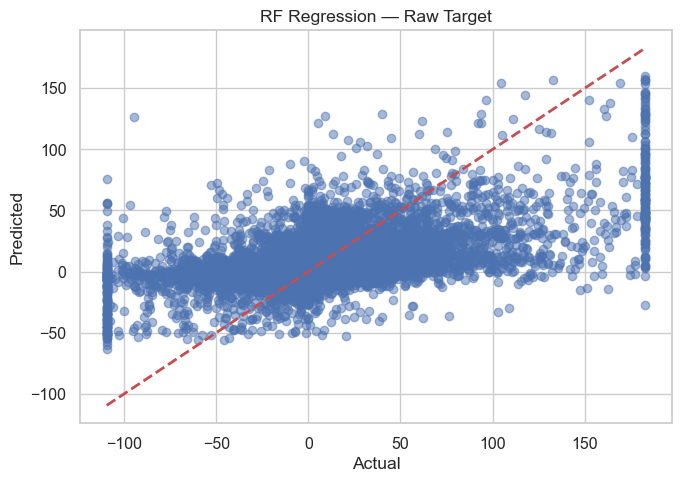

In [7]:
# ── 2.1 Train RF on raw regression target ───────────────────────────
print('='*60)
print('  Random Forest — Regression (Raw Target)')
print('='*60)

tkey = 'regression_raw'
data = prepare_target_splits(tkey)
if data:
    data = subset_prepared_data(data, SAFE_FEATURES)

if data:
    rf_reg = RandomForestRegressor(**RF_REG_PARAMS)
    if data['w_train'] is not None:
        rf_reg.fit(data['X_train'], data['y_train'], sample_weight=data['w_train'])
    else:
        rf_reg.fit(data['X_train'], data['y_train'])

    y_pred_train = rf_reg.predict(data['X_train'])
    y_pred = rf_reg.predict(data['X_test'])
    train_metrics = evaluate_regression(data['y_train'], y_pred_train)
    metrics = evaluate_regression(data['y_test'], y_pred)
    print('Train metrics:', train_metrics)
    print('Test metrics:', metrics)

    plot_regression_results(data['y_test'], y_pred, 'RF Regression — Raw Target')
    trained_models[tkey] = rf_reg
    trained_model_features[tkey] = data['feature_names']
    summary_rows.append({'Target': tkey, 'Model': 'Regressor', **to_serializable(metrics)})
else:
    print(f'⚠️  Target "{tkey}" not available')


---

## 3. Random Forest for Regression — Log-Transformed Target (`target_log`)

We train a Random Forest to predict the **log-transformed** target value.

  Random Forest — Regression (Log Target)
   Train: (77455, 19) | Val: (16597, 19) | Test: (16598, 19)
   Using leakage-safe features (8): ['EXPN.ha_scaled', 'LAT_scaled', 'LON_scaled', 'eco.EXPN.ha_scaled', 'feat_lat_bin', 'feat_lat_x_eco1', 'feat_lon_bin', 'state.EXPN.ha_scaled']
   Safe Train: (77455, 8) | Safe Val: (16597, 8) | Safe Test: (16598, 8)
Train metrics: {'MAE': 1.8740640319799808, 'MSE': 4.9676416742260185, 'RMSE': np.float64(2.2288206913581043), 'R2': 0.29635309477650584}
Test metrics: {'MAE': 1.9426951689081673, 'MSE': 5.3249819888923, 'RMSE': np.float64(2.3075922492702863), 'R2': 0.23670631183415392}


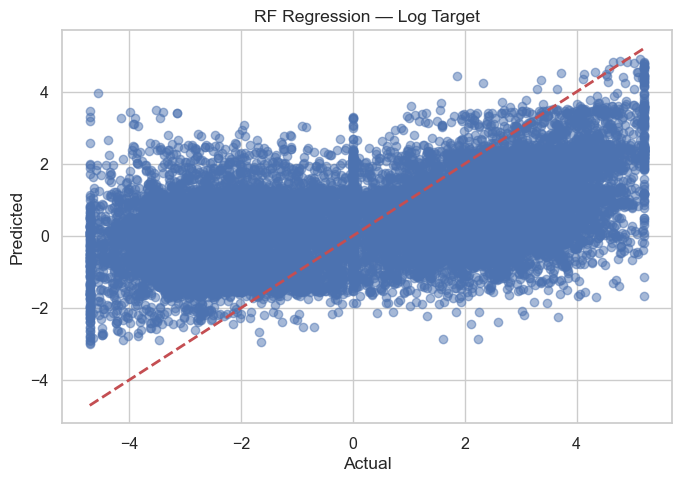

In [8]:
# ── 3.1 Train RF on log regression target ───────────────────────────
print('='*60)
print('  Random Forest — Regression (Log Target)')
print('='*60)

tkey = 'regression_log'
data = prepare_target_splits(tkey)
if data:
    data = subset_prepared_data(data, SAFE_FEATURES)

if data:
    rf_log = RandomForestRegressor(**RF_REG_PARAMS)
    if data['w_train'] is not None:
        rf_log.fit(data['X_train'], data['y_train'], sample_weight=data['w_train'])
    else:
        rf_log.fit(data['X_train'], data['y_train'])

    y_pred_train = rf_log.predict(data['X_train'])
    y_pred = rf_log.predict(data['X_test'])
    train_metrics = evaluate_regression(data['y_train'], y_pred_train)
    metrics = evaluate_regression(data['y_test'], y_pred)
    print('Train metrics:', train_metrics)
    print('Test metrics:', metrics)

    plot_regression_results(data['y_test'], y_pred, 'RF Regression — Log Target')
    trained_models[tkey] = rf_log
    trained_model_features[tkey] = data['feature_names']
    summary_rows.append({'Target': tkey, 'Model': 'Regressor', **to_serializable(metrics)})
else:
    print(f'⚠️  Target "{tkey}" not available')


---

## 4. Random Forest for Binary Classification (`target_binary`)

## 4.0 Random Forest Hyperparameter Configuration Comparison

This section evaluates five Random Forest configurations for the **binary classification** task using only the leakage-safe feature subset. The best configuration is selected using **validation F1-score**.


In [9]:
# ── 4.0 Compare 5 RF configurations on binary classification ───────
RF_CONFIGS = [
    {'label': 'n=50, max_depth=None',  'n_estimators': 50,  'max_depth': None},
    {'label': 'n=100, max_depth=None', 'n_estimators': 100, 'max_depth': None},
    {'label': 'n=200, max_depth=None', 'n_estimators': 200, 'max_depth': None},
    {'label': 'n=100, max_depth=10',   'n_estimators': 100, 'max_depth': 10},
    {'label': 'n=100, max_depth=20',   'n_estimators': 100, 'max_depth': 20},
]

print('=' * 70)
print('Random Forest — 5 Configuration Comparison (Leakage-Safe Features)')
print('=' * 70)

config_data = prepare_target_splits('binary_classification')
if config_data:
    config_data = subset_prepared_data(config_data, SAFE_FEATURES)

rf_config_rows = []

if config_data:
    for cfg in RF_CONFIGS:
        print(f"\nRunning {cfg['label']} ...")
        model = RandomForestClassifier(
            n_estimators=cfg['n_estimators'],
            max_depth=cfg['max_depth'],
            random_state=RANDOM_STATE,
            n_jobs=-1,
            min_samples_split=10,
            min_samples_leaf=4,
            max_features='sqrt',
            class_weight='balanced',
        )

        if config_data['w_train'] is not None:
            model.fit(config_data['X_train'], config_data['y_train'], sample_weight=config_data['w_train'])
        else:
            model.fit(config_data['X_train'], config_data['y_train'])

        y_train_pred = model.predict(config_data['X_train'])
        y_val_pred = model.predict(config_data['X_val'])
        y_test_pred = model.predict(config_data['X_test'])

        train_metrics = evaluate_classification(config_data['y_train'], y_train_pred, average='binary')
        val_metrics = evaluate_classification(config_data['y_val'], y_val_pred, average='binary')
        test_metrics = evaluate_classification(config_data['y_test'], y_test_pred, average='binary')

        rf_config_rows.append({
            'Configuration': cfg['label'],
            'Train Accuracy': train_metrics['Accuracy'],
            'Train Precision': train_metrics['Precision'],
            'Train Recall': train_metrics['Recall'],
            'Train F1-Score': train_metrics['F1'],
            'Val Accuracy': val_metrics['Accuracy'],
            'Val Precision': val_metrics['Precision'],
            'Val Recall': val_metrics['Recall'],
            'Val F1-Score': val_metrics['F1'],
            'Test Accuracy': test_metrics['Accuracy'],
            'Test Precision': test_metrics['Precision'],
            'Test Recall': test_metrics['Recall'],
            'Test F1-Score': test_metrics['F1'],
        })

    rf_config_df = pd.DataFrame(rf_config_rows)
    display(rf_config_df.round(4))

    best_idx = rf_config_df['Val F1-Score'].idxmax()
    best_rf_config = rf_config_df.loc[best_idx].to_dict()
    print('\nBest configuration based on Validation F1:')
    print(best_rf_config)

    rf_report_df = rf_config_df.copy()
    for col in ['Val Accuracy', 'Val Precision', 'Val Recall', 'Test Accuracy', 'Test Precision', 'Test Recall']:
        rf_report_df[col] = (rf_report_df[col] * 100).round(1).astype(str) + '%'
    rf_report_df['Val F1-Score'] = rf_report_df['Val F1-Score'].round(3)
    rf_report_df['Test F1-Score'] = rf_report_df['Test F1-Score'].round(3)
    display(rf_report_df[['Configuration', 'Val Accuracy', 'Val Precision', 'Val Recall', 'Val F1-Score']])

    rf_config_df.to_csv(os.path.join(REPORTS_DIR, 'rf_safe_feature_config_comparison.csv'), index=False)
    print('\nSaved:', os.path.join(REPORTS_DIR, 'rf_safe_feature_config_comparison.csv'))
else:
    print('⚠️  Binary target not available for configuration comparison')


Random Forest — 5 Configuration Comparison (Leakage-Safe Features)
   Train: (77455, 19) | Val: (16597, 19) | Test: (16598, 19)
   Using leakage-safe features (8): ['EXPN.ha_scaled', 'LAT_scaled', 'LON_scaled', 'eco.EXPN.ha_scaled', 'feat_lat_bin', 'feat_lat_x_eco1', 'feat_lon_bin', 'state.EXPN.ha_scaled']
   Safe Train: (77455, 8) | Safe Val: (16597, 8) | Safe Test: (16598, 8)

Running n=50, max_depth=None ...

Running n=100, max_depth=None ...

Running n=200, max_depth=None ...

Running n=100, max_depth=10 ...

Running n=100, max_depth=20 ...


,Configuration,Train Accuracy,Train Precision,Train Recall,Train F1-Score,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,"n=50, max_depth=None",0.8480,0.8667,0.8543,0.8605,0.6848,0.7118,0.7106,0.7112,0.6827,0.7140,0.7014,0.7076
1,"n=100, max_depth=None",0.8506,0.8692,0.8567,0.8629,0.6843,0.7118,0.7090,0.7104,0.6844,0.7167,0.7001,0.7083
2,"n=200, max_depth=None",0.8529,0.8716,0.8584,0.8650,0.6854,0.7126,0.7104,0.7115,0.6842,0.7156,0.7024,0.7089
3,"n=100, max_depth=10",0.6978,0.7363,0.6999,0.7176,0.6730,0.7105,0.6770,0.6934,0.6725,0.7103,0.6785,0.6940
4,"n=100, max_depth=20",0.8216,0.8429,0.8293,0.8361,0.6872,0.7148,0.7109,0.7128,0.6828,0.7140,0.7015,0.7077



Best configuration based on Validation F1:
{'Configuration': 'n=100, max_depth=20', 'Train Accuracy': 0.8215738170550643, 'Train Precision': 0.842948717948718, 'Train Recall': 0.8293015813253012, 'Train F1-Score': 0.8360694628961852, 'Val Accuracy': 0.687172380550702, 'Val Precision': 0.7148086522462562, 'Val Recall': 0.7108659680088252, 'Val F1-Score': 0.7128318584070796, 'Test Accuracy': 0.6827931076033257, 'Test Precision': 0.7140136664052873, 'Test Recall': 0.7015188201628879, 'Test F1-Score': 0.7077110975406651}


,Configuration,Val Accuracy,Val Precision,Val Recall,Val F1-Score
0,"n=50, max_depth=None",68.5%,71.2%,71.1%,0.711
1,"n=100, max_depth=None",68.4%,71.2%,70.9%,0.710
2,"n=200, max_depth=None",68.5%,71.3%,71.0%,0.712
3,"n=100, max_depth=10",67.3%,71.1%,67.7%,0.693
4,"n=100, max_depth=20",68.7%,71.5%,71.1%,0.713



Saved: outputs\reports\rf_safe_feature_config_comparison.csv


We now train the **final binary Random Forest model** using the best validation configuration and the same leakage-safe feature subset.


  Random Forest — Binary Classification (Final Model)
   Train: (77455, 19) | Val: (16597, 19) | Test: (16598, 19)
   Using leakage-safe features (8): ['EXPN.ha_scaled', 'LAT_scaled', 'LON_scaled', 'eco.EXPN.ha_scaled', 'feat_lat_bin', 'feat_lat_x_eco1', 'feat_lon_bin', 'state.EXPN.ha_scaled']
   Safe Train: (77455, 8) | Safe Val: (16597, 8) | Safe Test: (16598, 8)
Train metrics: {'Accuracy': 0.8215738170550643, 'Precision': 0.842948717948718, 'Recall': 0.8293015813253012, 'F1': 0.8360694628961852, 'ROC_AUC': 0.910269367596857}
Test metrics: {'Accuracy': 0.6827931076033257, 'Precision': 0.7140136664052873, 'Recall': 0.7015188201628879, 'F1': 0.7077110975406651, 'ROC_AUC': 0.7561972895608571}

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.66      0.65      7512
           1       0.71      0.70      0.71      9086

    accuracy                           0.68     16598
   macro avg       0.68      0.68      0.68     16598
wei

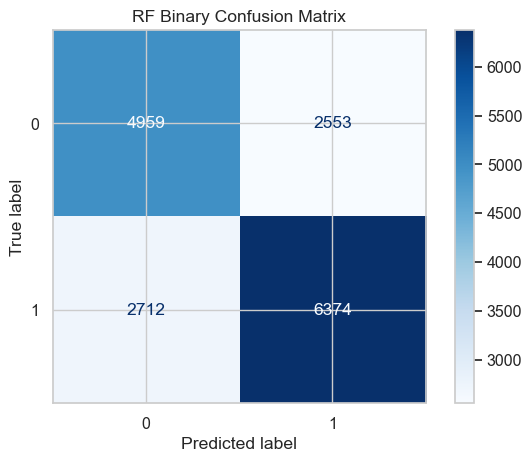

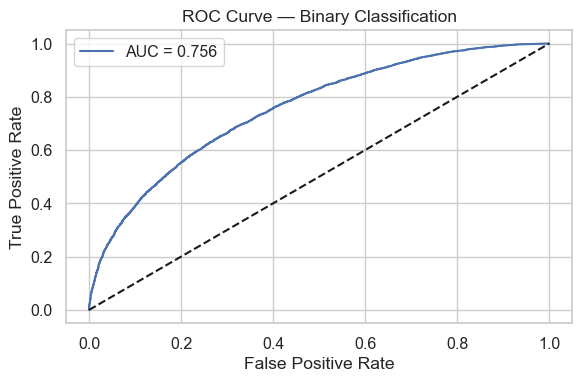

In [10]:
# ── 4.1 Train final RF on binary classification target ──────────────
print('='*60)
print('  Random Forest — Binary Classification (Final Model)')
print('='*60)

tkey = 'binary_classification'
data = prepare_target_splits(tkey)
if data:
    data = subset_prepared_data(data, SAFE_FEATURES)

if data:
    final_params = {
        'n_estimators': 100,
        'max_depth': 20,
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'min_samples_split': 10,
        'min_samples_leaf': 4,
        'max_features': 'sqrt',
        'class_weight': 'balanced',
    }

    rf_bin = RandomForestClassifier(**final_params)
    if data['w_train'] is not None:
        rf_bin.fit(data['X_train'], data['y_train'], sample_weight=data['w_train'])
    else:
        rf_bin.fit(data['X_train'], data['y_train'])

    y_pred_train = rf_bin.predict(data['X_train'])
    y_pred = rf_bin.predict(data['X_test'])
    y_proba_train = rf_bin.predict_proba(data['X_train'])[:, 1] if hasattr(rf_bin, 'predict_proba') else None
    y_proba = rf_bin.predict_proba(data['X_test'])[:, 1] if hasattr(rf_bin, 'predict_proba') else None

    train_metrics = evaluate_classification(data['y_train'], y_pred_train, y_proba_train, average='binary')
    metrics = evaluate_classification(data['y_test'], y_pred, y_proba, average='binary')
    print('Train metrics:', train_metrics)
    print('Test metrics:', metrics)

    print('\nClassification Report:')
    print(classification_report(data['y_test'], y_pred, zero_division=0))
    plot_confusion(data['y_test'], y_pred, 'RF Binary Confusion Matrix')

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(data['y_test'], y_proba)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f'AUC = {metrics.get("ROC_AUC", 0):.3f}')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve — Binary Classification')
        plt.legend()
        plt.tight_layout()
        plt.show()

    trained_models[tkey] = rf_bin
    trained_model_features[tkey] = data['feature_names']
    summary_rows.append({'Target': tkey, 'Model': 'Classifier', **to_serializable(metrics)})
else:
    print(f'⚠️  Target "{tkey}" not available')


---

## 5. Random Forest for Multiclass Classification (`target_class3`)

We train a Random Forest to choose **1 of 3 classes** for the multiclass target.

  Random Forest — Multiclass Classification
   Train: (77455, 19) | Val: (16597, 19) | Test: (16598, 19)
   Using leakage-safe features (8): ['EXPN.ha_scaled', 'LAT_scaled', 'LON_scaled', 'eco.EXPN.ha_scaled', 'feat_lat_bin', 'feat_lat_x_eco1', 'feat_lon_bin', 'state.EXPN.ha_scaled']
   Safe Train: (77455, 8) | Safe Val: (16597, 8) | Safe Test: (16598, 8)
Train metrics: {'Accuracy': 0.589568136337228, 'Precision': 0.5883218745729933, 'Recall': 0.589056330495722, 'F1': 0.5884846494532477}
Test metrics: {'Accuracy': 0.537474394505362, 'Precision': 0.5364719734550678, 'Recall': 0.536933141985552, 'F1': 0.5365555288328635}

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.56      0.55      5462
           1       0.49      0.47      0.48      5462
           2       0.58      0.58      0.58      5674

    accuracy                           0.54     16598
   macro avg       0.54      0.54      0.54     16598
weighted avg       0.54

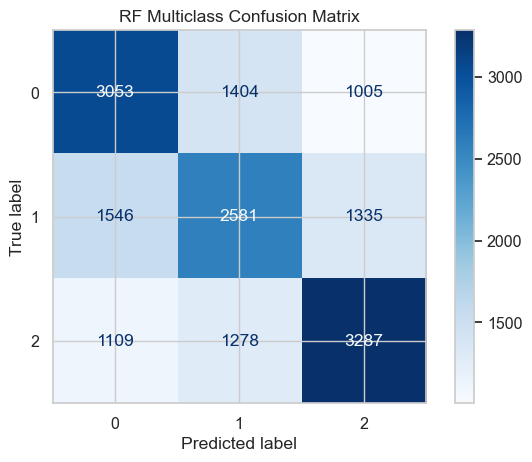

In [11]:
# ── 5.1 Train RF on multiclass target ────────────────────────────────
print('='*60)
print('  Random Forest — Multiclass Classification')
print('='*60)

tkey = 'multiclass_3'
data = prepare_target_splits(tkey)
if data:
    data = subset_prepared_data(data, SAFE_FEATURES)

if data:
    rf_multi = RandomForestClassifier(**RF_CLF_PARAMS)
    if data['w_train'] is not None:
        rf_multi.fit(data['X_train'], data['y_train'], sample_weight=data['w_train'])
    else:
        rf_multi.fit(data['X_train'], data['y_train'])

    y_pred_train = rf_multi.predict(data['X_train'])
    y_pred = rf_multi.predict(data['X_test'])
    train_metrics = evaluate_classification(data['y_train'], y_pred_train, average='macro')
    metrics = evaluate_classification(data['y_test'], y_pred, average='macro')
    print('Train metrics:', train_metrics)
    print('Test metrics:', metrics)

    print('\nClassification Report:')
    print(classification_report(data['y_test'], y_pred, zero_division=0))
    plot_confusion(data['y_test'], y_pred, 'RF Multiclass Confusion Matrix')

    trained_models[tkey] = rf_multi
    trained_model_features[tkey] = data['feature_names']
    summary_rows.append({'Target': tkey, 'Model': 'Classifier', **to_serializable(metrics)})
else:
    print(f'⚠️  Target "{tkey}" not available')


---

## 6. Feature Importance Analysis

Feature importance shows which input clues are most helpful.

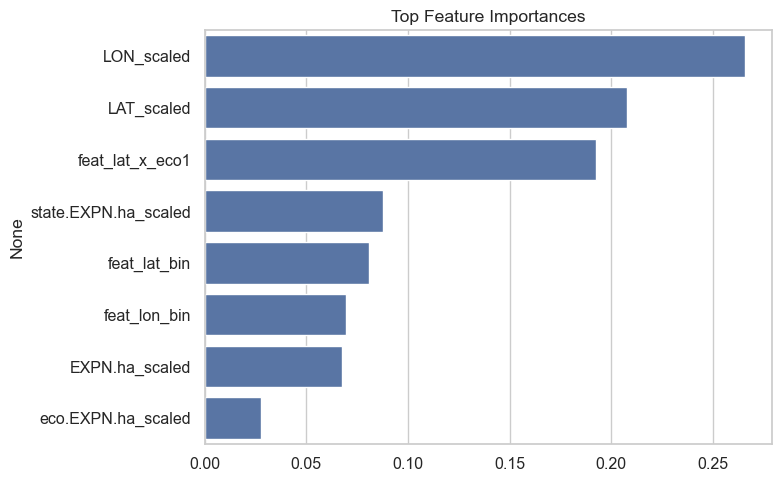

In [12]:
# ── 6.1 Feature importances (use log regression if available) ────────
model_key = 'regression_log' if 'regression_log' in trained_models else 'regression_raw'
model_for_importance = trained_models.get(model_key)
feature_names_for_importance = trained_model_features.get(model_key, SAFE_FEATURES)

if model_for_importance is not None:
    plot_feature_importance(model_for_importance, feature_names_for_importance, top_n=15)
else:
    print('⚠️  No regression model available for feature importance')


---

## 7. Summary — All Targets

This table compares all model results in one place.

,Target,Model,MAE,MSE,RMSE,R2,Accuracy,Precision,Recall,F1,ROC_AUC
0,regression_raw,Regressor,19.3937,958.3301,30.9569,0.2908,NaN,NaN,NaN,NaN,NaN
1,regression_log,Regressor,1.9427,5.3250,2.3076,0.2367,NaN,NaN,NaN,NaN,NaN
2,binary_classification,Classifier,NaN,NaN,NaN,NaN,0.6828,0.7140,0.7015,0.7077,0.7562
3,multiclass_3,Classifier,NaN,NaN,NaN,NaN,0.5375,0.5365,0.5369,0.5366,NaN


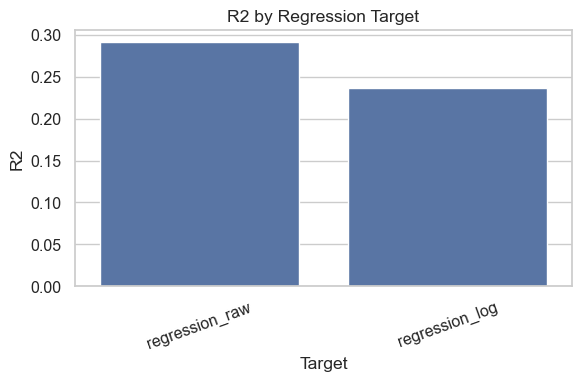

In [13]:
# ── 7.1 Summary table ────────────────────────────────────────────────

if summary_rows:

    summary_df = pd.DataFrame(summary_rows)

    display(summary_df.round(4))



    # Simple comparison chart for regression metrics

    reg_df = summary_df[summary_df['Model'] == 'Regressor']

    if not reg_df.empty:

        plt.figure(figsize=(6, 4))

        sns.barplot(data=reg_df, x='Target', y='R2')

        plt.title('R2 by Regression Target')

        plt.xticks(rotation=20)

        plt.tight_layout()

        plt.show()

else:

    print('⚠️  No results to summarize')

---

## 8. Save Models & Reports

We save the trained models and metrics so you can use them later.

In [14]:
# ── 8.1 Save trained models ──────────────────────────────────────────

for tkey, model in trained_models.items():

    model_path = os.path.join(MODELS_DIR, f'random_forest_{tkey}.joblib')

    joblib.dump(model, model_path)

    print(f'✅ Saved model: {model_path}')



# ── 8.2 Save metrics to JSON ─────────────────────────────────────────

if summary_rows:

    report_path = os.path.join(REPORTS_DIR, 'random_forest_metrics.json')

    with open(report_path, 'w') as f:

        json.dump(summary_rows, f, indent=2)

    print(f'✅ Saved metrics: {report_path}')

✅ Saved model: outputs\models\random_forest_regression_raw.joblib
✅ Saved model: outputs\models\random_forest_regression_log.joblib
✅ Saved model: outputs\models\random_forest_binary_classification.joblib
✅ Saved model: outputs\models\random_forest_multiclass_3.joblib
✅ Saved metrics: outputs\reports\random_forest_metrics.json


---

## 🏁 Summary

This notebook trained Random Forest models for **regression** and **classification**, generated evaluation plots, and saved metrics/models for reporting.